# <B>Lec10. [실습] 뉴스 감성분석
* 금융뉴스 감성 사전 : https://github.com/ukairia777/finance_sentiment_corpus

<pre>finance_data.csv
언어 : 영어, 한국어
출처 : Finance Phrase Bank (Malo et al., 2014)
데이터 건수 : 4,846건
    
영어 데이터
Finance Phrase Bank (Malo et al., 2014)
금융 뉴스 데이터에서 4,840여개의 문장 추출
16명의 전문지식을 갖춘 연구자들에 의해 수동 라벨링하여 만들었음.    
감정 라벨 : positive, neutral, negative
    
한국어 데이터
위 데이터를 한국어로 번역 및 검수한 데이터.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
from konlpy.tag import Okt

from tqdm import tqdm
from nltk.corpus import stopwords

from collections import Counter
from konlpy.tag import Mecab
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import Embedding, Dense, GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from wordcloud import WordCloud

import warnings
warnings.filterwarnings(action='ignore')
sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
#plt.rc('font', family='NanumGothicOTF') # For MacOS
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
from IPython.core.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)


# <b>Data Load (감성사전)

In [2]:
df = pd.read_csv("./dataset/lec10_finance_data.csv" )
df = df[ ['labels', 'kor_sentence'] ]
df.columns = ['label','kor']
df.head(2)

,label,kor
0,neutral,"Gran에 따르면, 그 회사는 회사가 성장하고 있는 곳이지만, 모든 생산을 러시아로 옮길 계획이 없다고 한다."
1,neutral,테크노폴리스는 컴퓨터 기술과 통신 분야에서 일하는 회사들을 유치하기 위해 10만 평방미터 이상의 면적을 단계적으로 개발할 계획이라고 성명은 밝혔다.


# <b>전처리 & 가공

## 결측제거

In [3]:
print(df.shape)
df = df.dropna(subset="kor")
print(df.shape)

(4846, 2)
(4846, 2)


## 중복제거

In [4]:
print(df.shape)
df  = df.drop_duplicates(subset="kor")
print(df.shape)

(4846, 2)
(4827, 2)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4827 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   4827 non-null   object
 1   kor     4827 non-null   object
dtypes: object(2)
memory usage: 113.1+ KB


## 한글만

In [6]:
df['kor_한글만'] = df['kor'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣]","", regex=True)
df.head(3)

,label,kor,kor_한글만
0,neutral,"Gran에 따르면, 그 회사는 회사가 성장하고 있는 곳이지만, 모든 생산을 러시아로 옮길 계획이 없다고 한다.",에따르면그회사는회사가성장하고있는곳이지만모든생산을러시아로옮길계획이없다고한다
1,neutral,테크노폴리스는 컴퓨터 기술과 통신 분야에서 일하는 회사들을 유치하기 위해 10만 평방미터 이상의 면적을 단계적으로 개발할 계획이라고 성명은 밝혔다.,테크노폴리스는컴퓨터기술과통신분야에서일하는회사들을유치하기위해만평방미터이상의면적을단계적으로개발할계획이라고성명은밝혔다
2,negative,"국제 전자산업 회사인 엘코텍은 탈린 공장에서 수십 명의 직원을 해고했으며, 이전의 해고와는 달리 회사는 사무직 직원 수를 줄였다고 일간 포스티메스가 보도했다.",국제전자산업회사인엘코텍은탈린공장에서수십명의직원을해고했으며이전의해고와는달리회사는사무직직원수를줄였다고일간포스티메스가보도했다


## 불용어 처리

In [7]:
stop_words_list = stopwords.words('my_korean')    #----C:\Users\user\..\stopwords\my_korean.txt
print('불용어 개수 :', len(stop_words_list))
print('불용어 10개 출력 :',stop_words_list[:10])

불용어 개수 : 595
불용어 10개 출력 : ['가', '가까스로', '가령', '각', '각각', '각자', '각종', '갖고말하자면', '같다', '같이']


In [8]:
mecab = Mecab(dicpath=r"C:/mecab/mecab-ko-dic") 
#okt = Okt()

tokenized_data = []
for sentence in tqdm(df['kor_한글만']):
    tokenized_sentence = mecab.morphs(sentence)               # 형태소 토큰화
    #tokenized_sentence = okt.morphs(sentence, stem=True)
    
    #불용어단어, 1글자 버리기
    stopwords_removed_sentence = [word for word in tokenized_sentence if word not in stop_words_list]  ## and len(word)>1] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4827/4827 [00:00<00:00, 5379.57it/s]


In [9]:
# tokenized_data[:2]

# [['따르','면','회사','는', ...] , [...] ]

리뷰의 최대 단어 길이 : 44
리뷰의 평균 단어 길이 : 16.19432359643671


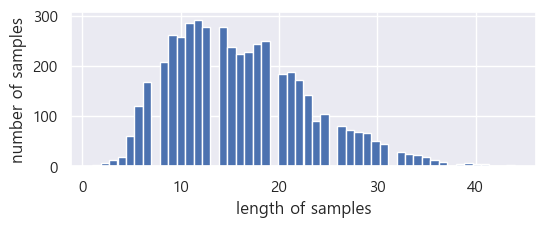

In [17]:
# 리뷰 길이 분포 확인
print('리뷰의 최대 단어 길이 :',max(len(review) for review in tokenized_data))
print('리뷰의 평균 단어 길이 :',sum(map(len, tokenized_data))/len(tokenized_data))
plt.figure(figsize=(6,2))
plt.hist([len(review) for review in tokenized_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [19]:
def below_threshold_len(max_len, nested_list):
    count = 0
    for sentence in nested_list:
        if(len(sentence) <= max_len):
            count = count + 1
    print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s' % (max_len, (count / len(nested_list)) * 100))

max_len = 35
below_threshold_len(max_len, tokenized_data)

전체 샘플 중 길이가 35 이하인 샘플의 비율: 99.08846074166149


In [10]:
temp_list = []
for data in tokenized_data:
    temp_list.append( " ".join(data))
temp_list[:2]    
df['kor_형태소불용'] = temp_list
df.head(2)

,label,kor,kor_한글만,kor_형태소불용
0,neutral,"Gran에 따르면, 그 회사는 회사가 성장하고 있는 곳이지만, 모든 생산을 러시아로 옮길 계획이 없다고 한다.",에따르면그회사는회사가성장하고있는곳이지만모든생산을러시아로옮길계획이없다고한다,따르 면 회사 는 회사 성장 고 있 는 곳 모든 생산 러시아 옮길 계획 없 다고 한다
1,neutral,테크노폴리스는 컴퓨터 기술과 통신 분야에서 일하는 회사들을 유치하기 위해 10만 평방미터 이상의 면적을 단계적으로 개발할 계획이라고 성명은 밝혔다.,테크노폴리스는컴퓨터기술과통신분야에서일하는회사들을유치하기위해만평방미터이상의면적을단계적으로개발할계획이라고성명은밝혔다,테크노폴리스 는 컴퓨터 기술 통신 분야 는 회사 유치 기 위해 만 평방 미터 면적 단계 적 개발 할 계획 라고 성명 은 밝혔 다


## 타겟 피쳐(label)인코딩

In [11]:
df['label'].value_counts()

label
neutral     2861
positive    1362
negative     604
Name: count, dtype: int64

In [12]:
df['label'] = df['label'].str.strip()
df['label'] = df['label'].map({'negative': 0,'neutral': 1,'positive': 2})
df['label'].value_counts()

label
1    2861
2    1362
0     604
Name: count, dtype: int64

In [13]:
print(df['label'].value_counts(dropna=False))

label
1    2861
2    1362
0     604
Name: count, dtype: int64


# train test 분리

In [14]:
X = df['kor_형태소불용']
y = df['label']
X80, X20, y80, y20 = train_test_split(X, y, test_size=0.15, random_state=8745, stratify=y)

# 사전 --> 임베딩 --> 패딩
* 자르기 --> 사전만들기 --> 임베딩(글자/숫자 바꾸기) --> 패딩

## 사전

In [15]:
tokenizer = Tokenizer( oov_token = 'OOV')  
tokenizer.fit_on_texts(X80)

vocab = tokenizer.word_index
print( f"4827개 문장 한글만, 불용처리, 형태소 처리 후 유니크 단어 갯수(사전크기) :  {len(vocab)}" ) 
# X80 = tokenizer.texts_to_sequences(X80)
# X20 = tokenizer.texts_to_sequences(X20)

# max_len = 100
# X80 = pad_sequences(X80, maxlen=max_len, padding='pre')
# X20 = pad_sequences(X20, maxlen=max_len, padding='pre')

4827개 문장 한글만, 불용처리, 형태소 처리 후 유니크 단어 갯수(사전크기) :  7574


## 임베딩

In [16]:
tokenizer = Tokenizer(len(vocab)+2, oov_token = 'OOV')
tokenizer.fit_on_texts(X80)

X80 = tokenizer.texts_to_sequences(X80)
X20 = tokenizer.texts_to_sequences(X20)

## 패딩

In [20]:
# max_len = 100
X80 = pad_sequences(X80, padding='pre', maxlen=max_len)
X20 = pad_sequences(X20, padding='pre', maxlen=max_len)

In [21]:
X80.shape, X20.shape

((4102, 35), (725, 35))

# 모델

In [22]:
embedding_dim = 100
hidden_units = 128
vocab_size = len(vocab) + 2

model = Sequential()
model.add(Embedding(vocab_size, embedding_dim, mask_zero=True))  
model.add(GRU(hidden_units))
model.add(Dense(1, activation='sigmoid'))

MY_STOP = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
MY_CHECK = ModelCheckpoint('best_model.keras', monitor='val_acc', mode='max', save_best_only=True)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)